# Section 1 &middot; Your First ML Loop

*The Honest Edge.*

We will run the entire supervised machine-learning loop, end to end, on the
simplest question a trader can ask: **will SPY close up tomorrow?**

The answer is going to be deflating, and the deflation is the whole point. By the
end you will have trained a real model, scored it honestly, and watched it tie a
brain-dead baseline. Understanding *why* is what makes everything later worth
doing.

## The loop, in one analogy: studying for an exam

Every supervised model does the same five things. Think of cramming from past
exam papers:

| ML term | Exam analogy | Here |
|---|---|---|
| **features (X)** | the clues on each question | numbers describing SPY *today* |
| **label (y)** | the answer key | did SPY go up *tomorrow*? |
| **train** | study past papers with answers | fit the model on old bars |
| **test** | sit a fresh, unseen exam | score it on later bars |
| **accuracy** | your exam score | % of days called correctly |

The flow:

```
candles  ->  features (X)  ->  label (y)  ->  fit  ->  predict  ->  score
```

One rule carries over from Section 0: **a score is meaningless until you know the
passing mark.** Hold that thought; it is the trap this whole section springs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from honest_edge import data, indicators as ind

spy = data.load_spy_daily()
print("shape:", spy.shape, " range:", spy.index.min().date(), "->", spy.index.max().date())

shape: (5000, 6)  range: 2006-05-05 -> 2026-03-20


## Step 1: features (the clues)

We hand the model six plain, textbook features. Every one is computed from data
**at or before today's close**, so we never peek at the future (the Section 0
contract):

| feature | meaning |
|---|---|
| `ret_1`, `ret_2`, `ret_3` | the last 1, 2, 3 daily returns |
| `mom_10` | 10-day momentum (return over 10 days) |
| `ma_dist` | how far price sits above/below its 20-day average |
| `rsi_14` | RSI(14): were recent moves lopsidedly up or down? |

Nothing exotic. The point is that *even a reasonable handful of the usual
indicators* will not move the needle.

In [2]:
# RSI(14) comes straight from the library (honest_edge/indicators.py), Wilder's
# smoothing, 0-100, high = recent moves were mostly up. We import it rather than
# re-typing it so the course has exactly ONE definition of every indicator;
# Section 3 calls the same ind.rsi() with length 2.
close = spy["close"]

# Copy-on-Write friendly: build an empty frame, then assign columns (no chained assignment).
feat = pd.DataFrame(index=spy.index)
feat["ret_1"] = close.pct_change(1)
feat["ret_2"] = close.pct_change(2)
feat["ret_3"] = close.pct_change(3)
feat["mom_10"] = close.pct_change(10)
feat["ma_dist"] = close / close.rolling(20).mean() - 1.0
feat["rsi_14"] = ind.rsi(close, 14)

feature_cols = list(feat.columns)
feat.tail(3)

,ret_1,ret_2,ret_3,mom_10,ma_dist,rsi_14
datetime,,,,,,
2026-03-18,-0.013954,-0.011360,-0.001299,-0.034592,-0.025805,36.255666
2026-03-19,-0.002464,-0.016384,-0.013796,-0.031572,-0.026436,35.317653
2026-03-20,-0.017020,-0.019443,-0.033125,-0.035412,-0.040113,29.629906


## Step 2: the label (the one place the future is allowed)

The answer key is "did tomorrow close higher than today?" We build it with
`shift(-1)`, which pulls *tomorrow's* close back onto *today's* row.

This is the single exception to the no-look-ahead rule: the label is allowed to
see the future because it is the answer we are trying to learn, **never an
input**. The very last row has no "tomorrow," so it becomes `NaN` and gets
dropped (not silently mislabeled).

In [3]:
future_close = close.shift(-1)                                   # tomorrow's close on today's row
# 1 = up, 0 = down. We use float (not int) so the final row, which has no
# "tomorrow", can stay NaN and be dropped, instead of being silently labeled 0.
y = (future_close > close).astype(float).where(future_close.notna())

# Glue features + label together and drop any row with a NaN (warm-up rows + the last bar).
dataset = feat.copy()
dataset["y"] = y
dataset = dataset.dropna()

X = dataset[feature_cols]
y = dataset["y"].astype(int)

print(f"usable rows: {len(dataset)}")
print(f"up-rate (share of up days): {y.mean():.2%}")
print("The deck is tilted up: that single fact is what the model will cling to.")

usable rows: 4980
up-rate (share of up days): 54.66%
The deck is tilted up: that single fact is what the model will cling to.


## Step 3: split by time, then train

We train on the **older** 75% of history and test on the **newer** 25%. Order
matters: shuffling days would let the model study tomorrow to predict yesterday,
exactly the leak Section 0 warned about. So this chronological split is the
honest default.

In [4]:
split = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

acc = accuracy_score(y_test, logreg.predict(X_test))
print(f"logistic regression test accuracy: {acc:.2%}")

logistic regression test accuracy: 54.06%


## Step 4: the baseline that gives the number meaning

A model that scores 54% sounds like it passed. But compare it to the dumbest
possible "strategy": **always guess up.** Since SPY rises more often than it
falls, that constant guess scores well for free. The gap between your model and
this baseline is the only thing that counts as skill.

**Analogy: a weighted coin.** SPY is not a fair coin; it is weighted ~54/46
toward heads (up). Calling "heads" every time is not insight, it is just knowing
the weighting, which we already knew.

In [5]:
baseline_acc = (y_test == 1).mean()        # "always predict up", measured on the TEST period
print(f"model accuracy:     {acc:.2%}")
print(f"always-up baseline: {baseline_acc:.2%}   (up-rate in the test window; the full-sample rate differs slightly)")
print(f"edge over baseline: {acc - baseline_acc:+.2%}")

model accuracy:     54.06%
always-up baseline: 54.06%   (up-rate in the test window; the full-sample rate differs slightly)
edge over baseline: +0.00%


This is the **accuracy paradox**: a respectable-looking 54% that is worth
*exactly zero*, because the do-nothing baseline scores the same. The tell to
remember: **when accuracy lands right on the up-rate, the model has probably just
learned to always predict the majority class.** Let's confirm that by looking at
how confident the model actually is.

learned weight per feature:
  ret_1    -0.615
  ret_2    -0.216
  ret_3    -0.054
  mom_10   -0.486
  ma_dist  -0.316
  rsi_14   -0.001

predicted P(up) only ranges 0.53 to 0.59:
every guess sits above 0.5, and barely. The model always whispers 'up'.


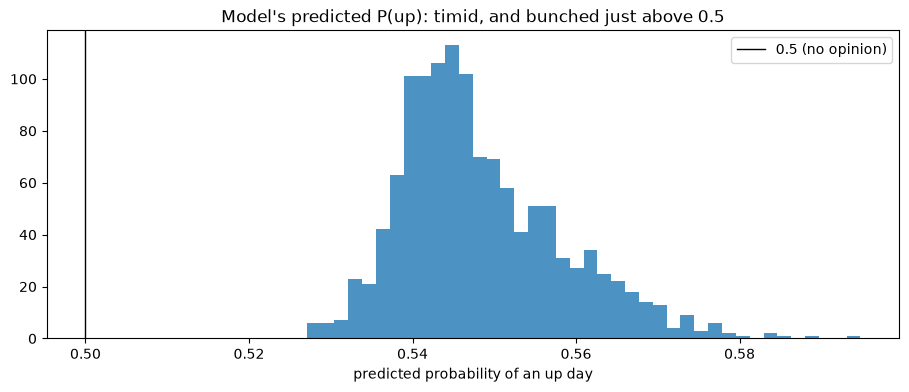

In [6]:
# The raw weights the model learned. We deliberately do NOT rank features by these:
# a weight's size depends on its feature's scale (RSI runs 0-100, returns run ~0.01),
# so the numbers are not comparable. The honest tell is the PROBABILITIES below.
print("learned weight per feature:")
for name, w in zip(feature_cols, logreg.coef_[0]):
    print(f"  {name:8s} {w:+.3f}")

proba_up = logreg.predict_proba(X_test)[:, 1]
print(f"\npredicted P(up) only ranges {proba_up.min():.2f} to {proba_up.max():.2f}:")
print("every guess sits above 0.5, and barely. The model always whispers 'up'.")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(proba_up, bins=40, alpha=0.8)
ax.axvline(0.5, color="k", lw=1, label="0.5 (no opinion)")
ax.set_title("Model's predicted P(up): timid, and bunched just above 0.5")
ax.set_xlabel("predicted probability of an up day")
ax.legend()
plt.show()

## "But what if we use a fancier model?"

The natural next move is to reach for something more powerful. Let's try a
**decision tree** with no limits and see what happens. Watch the gap between how
it does on the data it *studied* versus data it has *never seen*.

In [7]:
tree = DecisionTreeClassifier(random_state=0)   # unconstrained: free to memorize
tree.fit(X_train, y_train)

tree_train = accuracy_score(y_train, tree.predict(X_train))
tree_test = accuracy_score(y_test, tree.predict(X_test))
print(f"deep tree  train accuracy: {tree_train:.2%}   (memorized the past)")
print(f"deep tree  test  accuracy: {tree_test:.2%}   (learned nothing general)")

deep tree  train accuracy: 100.00%   (memorized the past)
deep tree  test  accuracy: 48.11%   (learned nothing general)


It scored ~100% on the training data and worse than a coin flip on new data. It
did not find a pattern; it **memorized noise**. More flexibility did not help, it
hurt. Here are all three side by side.

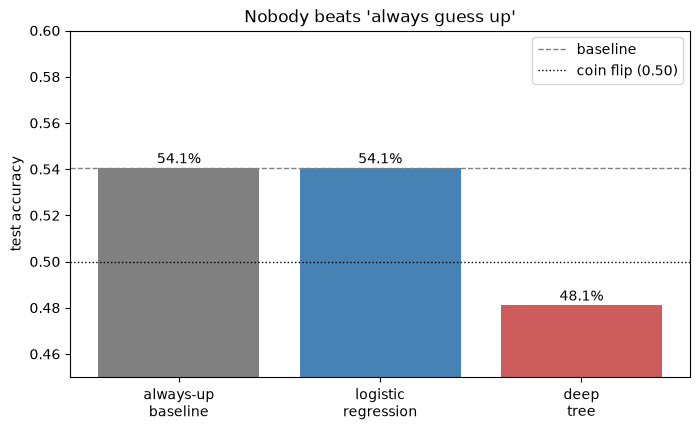

In [8]:
names = ["always-up\nbaseline", "logistic\nregression", "deep\ntree"]
scores = [baseline_acc, acc, tree_test]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(names, scores, color=["gray", "steelblue", "indianred"])
ax.axhline(baseline_acc, ls="--", color="gray", lw=1, label="baseline")
ax.axhline(0.50, ls=":", color="k", lw=1, label="coin flip (0.50)")
ax.set_ylim(0.45, 0.60)
ax.set_ylabel("test accuracy")
ax.set_title("Nobody beats 'always guess up'")
for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width() / 2, s + 0.002, f"{s:.1%}", ha="center")
ax.legend()
plt.show()

## Why a coin flip? (the real reason)

Tomorrow's daily return is **drift plus noise**, and the noise dwarfs the drift.
On our data the upward *drift* averages about **+0.04%** per day, but a single day
routinely swings **~1.2%** either way: the day-to-day noise is roughly **30x** the
size of the drift. The thing we want to predict (tomorrow's sign) is buried under
noise many times its size, noise that today's price-based features cannot see.
Markets are roughly efficient: any simple, public pattern in daily direction gets
traded away until only the slow upward drift and randomness remain.

**Analogy: the tide and the waves.** The tide (drift) is real but slow; the
individual waves (daily moves) are chaos. You can know the tide is coming in and
still not call the next wave. Our model learned the tide ("always up") and,
honestly, that is all there was to learn.

This result is **expected, not a bug.** It is exactly why the rest of the course
stops trying to predict direction and instead *filters a signal we already trust*.

## A cliffhanger: a tempting shortcut

What if we had split the data the lazy way, shuffling the days at random instead
of respecting time? It is one keyword change, `shuffle=True`. Watch what it does
to the score, and ask whether anything *real* changed.

In [9]:
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=0)
acc_shuffled = accuracy_score(ys_te, LogisticRegression(max_iter=1000).fit(Xs_tr, ys_tr).predict(Xs_te))

print(f"chronological (honest) accuracy: {acc:.2%}")
print(f"shuffled-split accuracy:         {acc_shuffled:.2%}")
print("\nShuffling moved the score, but it moved for FREE: we added no skill, we just")
print("reshuffled which days landed in the test set. The number now reflects the luck")
print("of the split, not the model. On this no-signal problem the change is small and")
print("could go either way. The real danger is what this same trick does to a problem")
print("that DOES contain a pattern, which is exactly where Section 2 begins.")

chronological (honest) accuracy: 54.06%
shuffled-split accuracy:         53.98%

Shuffling moved the score, but it moved for FREE: we added no skill, we just
reshuffled which days landed in the test set. The number now reflects the luck
of the split, not the model. On this no-signal problem the change is small and
could go either way. The real danger is what this same trick does to a problem
that DOES contain a pattern, which is exactly where Section 2 begins.


## Recap, and what's next

Five traps to carry forward, each one we just saw on screen:

1. **Accuracy vs baseline**: 54% means nothing next to a 54% baseline.
2. **The accuracy paradox**: when accuracy equals the up-rate, you have likely
   just predicted the majority class.
3. **Overfitting on noise**: the deep tree memorized the past and failed the future.
4. **Leakage via the split**: shuffling time changes the score for free; the
   number then reflects the split, not skill.
5. **One split is one die roll**: never trust a single number.

We ended on a loaded question: shuffling the data moved our score without adding
any skill. Here it barely budged, because there was no signal to inflate. But the
*mechanism* is dangerous. **Section 2** builds a problem that actually contains a
pattern, then shows how this very shuffle can manufacture a large fake edge, and
how honest validation, real trading costs, and proper baselines drag the truth
back into the open.